<center><img src="https://upload.wikimedia.org/wikipedia/commons/c/c3/Python-logo-notext.svg" width="08%" style="vertical-align: top; padding-top: 2px"></center>

<h1><font color='#306998'><center>KMeans Clustering</center></font></h1>
<center>Kannan Singaravelu, CQF</center>

---

## Clustering 
Clustering is a branch of unsupervised machine learning models that seeks to learn from the properties of the data by identifying groups or clusters in the dataset. Clustering is different from classification as it seeks to identify a set of similar data points and calling the resulting set a cluster. Selecting an appropriate clustering algorithm is often difficult due to the number of choices available. For a comprehensive survey of clustering algorithms, refer [here](https://link.springer.com/content/pdf/10.1007/s40745-015-0040-1.pdf). The three most popular categories of clustering algorithms are 


| Categories                | Clustering Algorithm                                        |
|:--------------------------|:------------------------------------------------------------|
|Partitional clustering     | Divides data objects into non overlapping groups            |
|Hierarchical clustering    | Assignments by building a hierarchy                         |
|Density-based clustering   | Assignments based on the density of data points in a region |


## K-Means Algorithm 
The $k$-means algorithm searches for a predetermined number of clusters within an unlabeled dataset and is based on the assumptions that the optimal cluster will have

* _“cluster center” which is the mean of all the points belonging to the cluster._
* _each point is closer to its own cluster center than to other cluster centers._

Conventional $k$-means algorithm requires only a few steps and follows a two-step process called **Expectation-Maximization** approach. This consists of

1. Randomly selecting $k$-centroids or _cluster center_
2. Repeat until converged<br>
    a. *E-Step*: assign points to the nearest _cluster center_ <br>
    b. *M-Step*: set the _cluster center_ to the mean

The "E-Step" or "Expectation Step" assigns each data point to its nearest centroid. Then, the "M-Step" or Maximization Step" computes the mean of all the points for each cluster and sets the new centroid. The $k$-means algorithms seeks to find $k$ clusters within a data set. The clusters are chosen to reduce the **inertia**, the objective function

$$ \min_{C_k} \sum_{k} \sum_{X_j \in  C_k} \| X_j  - \mu_k \|^2. $$

and the centroid of a cluster $\mu_k$ is equal to

$$ \mu_k = \frac{1}{|C_k|} \sum_{X_j \in C_k} X_j, $$

where $|C_k|$ is the number of points in cluster $k$. 

The cluster assignments are done based on squared Euclidean distance and algorithm tries to minimize the objective function. This process is repeated, iteratively, until the sum of the distance is minimized.

### Implementation 

In [1]:
# Base Libraries
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (20,10)
plt.style.use('fivethirtyeight')

# Set display options
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 10)

# set seed
np.random.seed(2025)

### Load the Dataset

Download the dataset from [here](https://github.com/kannansingaravelu/datasets/blob/main/dow_ohlc.npy) and place it in the data folder for access.

In [3]:
# Load dow ohlc dict and get the stock tickers
ohlc = np.load('./data/dow_ohlc.npy', allow_pickle='TRUE').item()
dow_stocks = sorted(list(ohlc.keys()))
dow_stocks[:10]

['AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'DOW']

In [4]:
# subsume into dataframe
df = pd.DataFrame({symbol: ohlc[symbol]['Close'] for symbol in dow_stocks})
df.head()

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,DOW,GS,HD,HON,IBM,INTC,JNJ,JPM,KO,MCD,MMM,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12-31,6.503574,45.404182,34.434761,41.856789,41.498463,18.442499,18.048286,50.924435,28.090706,NaN,144.296997,22.428135,29.058954,92.406113,14.717187,46.714996,31.395401,18.951757,45.094296,62.065166,25.193796,23.801456,12.066024,43.431492,38.205708,25.778193,17.935587,18.633041,28.350834,40.954620
2010-01-04,6.604801,46.327202,34.774685,43.441975,42.634403,18.705000,18.613705,52.293617,27.933924,NaN,147.920776,22.226564,29.911453,93.500313,15.063472,46.910812,32.323208,18.965061,45.339836,62.327927,25.517866,24.168472,11.934528,43.782478,38.167397,26.666224,18.075037,18.717409,28.798639,41.552284
2010-01-05,6.616219,45.925884,34.698196,44.864773,43.144135,18.625000,18.530785,52.664024,27.864237,NaN,150.535919,22.389368,29.970768,92.370834,15.056260,46.366856,32.949322,18.735643,44.993195,61.937550,25.621284,24.176279,11.982012,43.796806,37.263195,26.623932,17.867916,18.751152,28.567017,41.138515
2010-01-06,6.510980,45.580757,35.259079,46.225727,43.275200,18.592501,18.410154,52.670624,27.716166,NaN,148.929138,22.311846,29.970768,91.770790,15.005755,46.743999,33.130344,18.728989,44.379295,62.815929,25.966017,24.027906,11.908962,43.589062,36.734470,26.886124,17.627977,18.229431,28.350834,41.046570
2010-01-07,6.498945,45.163395,35.830952,48.097031,43.449959,18.510000,18.493084,52.472206,27.724878,NaN,151.843475,22.575434,30.548969,91.453102,14.861475,46.410374,33.786621,18.682440,44.704296,62.860950,26.007395,23.778025,12.025843,43.352684,37.263195,27.917923,17.792036,18.120922,28.520689,41.069557


In [5]:
# describe the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AAPL,2705.0,30.047436,21.270880,5.927071,14.999914,24.668011,40.598782,134.179993
AMGN,2705.0,122.692630,57.688231,38.742432,68.694923,132.670822,163.988373,259.213684
AXP,2705.0,71.997918,24.876817,31.401155,50.829639,72.261726,89.625107,135.558502
BA,2705.0,153.848461,106.307919,41.856789,61.374840,116.978035,194.325790,430.299988
CAT,2705.0,88.018466,29.550767,37.228798,66.677711,77.293983,115.443932,159.491608
CRM,2705.0,79.807642,50.328566,15.520000,38.060001,67.839996,109.150002,281.250000
CSCO,2705.0,26.304599,11.800751,10.426702,16.940058,22.859888,36.486423,55.699444
CVX,2705.0,86.346505,17.632351,45.367470,74.307068,87.029297,99.060753,119.106483
DIS,2705.0,80.097052,34.339309,25.536150,44.453819,89.787476,105.570000,150.736893
DOW,387.0,43.627492,6.573014,21.285501,40.732752,44.775864,48.306002,54.396061


### Check Missing Values

In [6]:
# Check for missing values
df.isnull().sum()   

AAPL       1
AMGN       1
AXP        1
BA         1
CAT        1
CRM        1
CSCO       1
CVX        1
DIS        1
DOW     2319
GS         1
HD         1
HON        1
IBM        1
INTC       1
JNJ        1
JPM        1
KO         1
MCD        1
MMM        1
MRK        1
MSFT       1
NKE        1
PG         1
TRV        1
UNH        1
V          1
VZ         1
WBA        1
WMT        1
dtype: int64

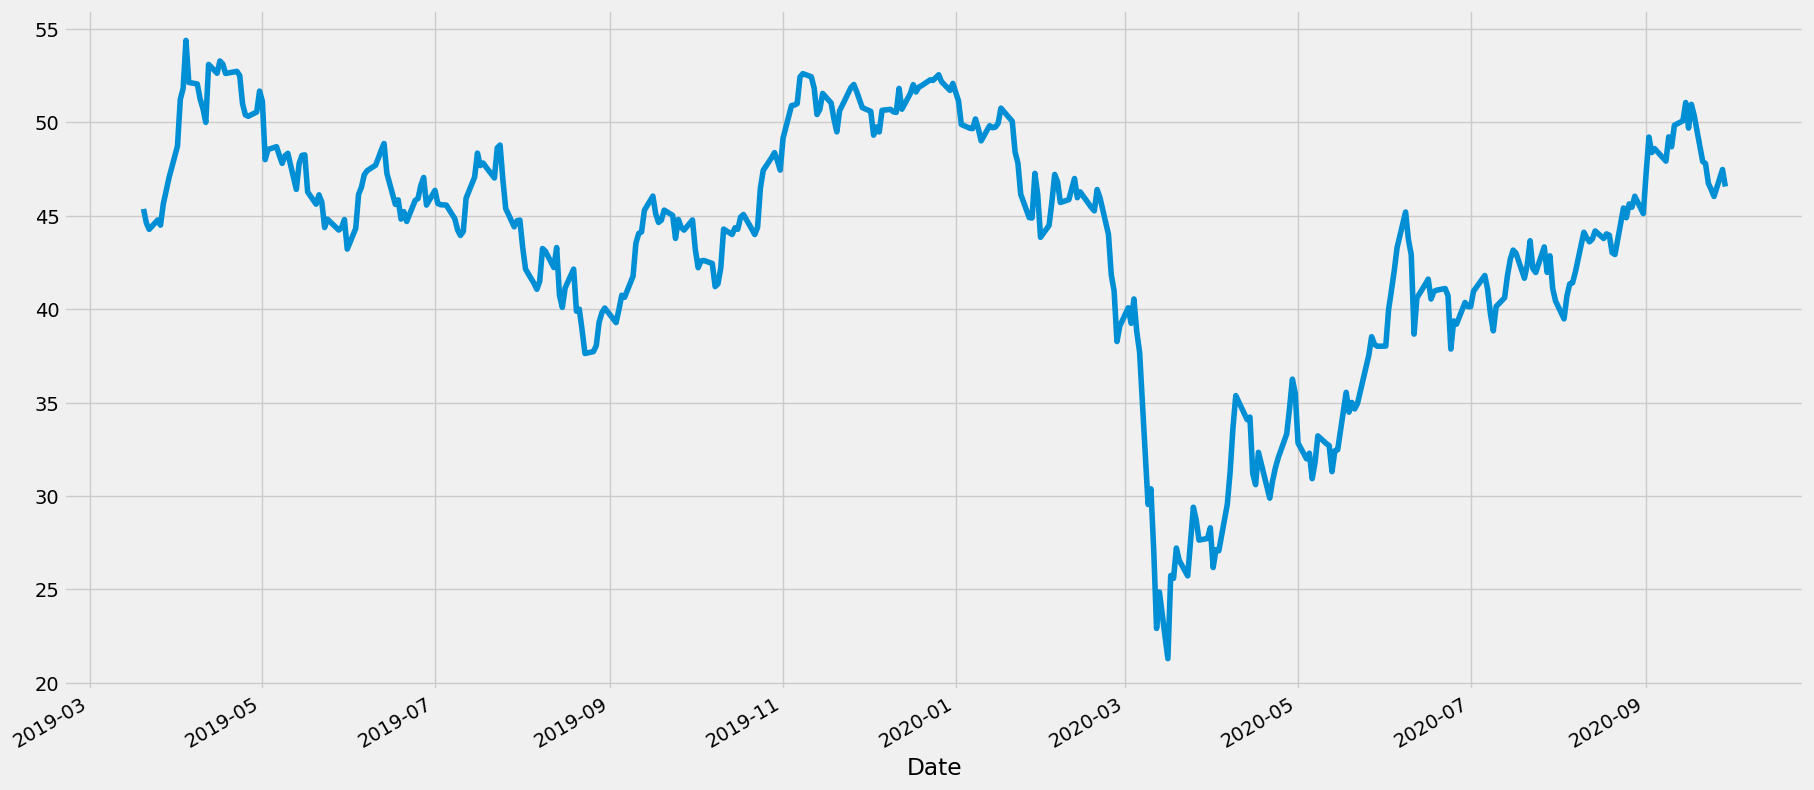

In [7]:
# plot dow close prices
ohlc['DOW']['Close'].plot();

In [8]:
# Get the index of the NaN values
[df[x].index[df[x].apply(np.isnan)] for x in dow_stocks]

[DatetimeIndex(['2016-01-18'], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex(['2016-01-18'], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex(['2016-01-18'], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex(['2016-01-18'], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex(['2016-01-18'], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex(['2016-01-18'], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex(['2016-01-18'], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex(['2016-01-18'], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex(['2016-01-18'], dtype='datetime64[ns]', name='Date', freq=None),
 DatetimeIndex(['2009-12-31',
                '2010-01-04',
                '2010-01-05',
                '2010-01-06',
                '2010-01-07',
                '2010-01-08',
                '2010-01-11',
                '2010-01-12',
                '2010-01-13',
          

### Impute Missing Values

In [9]:
# Fill forward the missing values and drop DOW from the list
df.fillna(method='ffill', axis=0, inplace=True)
df.drop(['DOW'], axis=1, inplace=True)
df.dropna(inplace=True)

/var/folders/sj/km6fyx_57pn857bnxsqvkj_80000gn/T/ipykernel_11254/4183225880.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', axis=0, inplace=True)


In [10]:
# Verify whether missing values are dropped
np.isnan(df.any()).sum()

np.int64(0)

In [11]:
# remove dow chemicals from the stock list
dow_stocks.remove('DOW')

### Add Features 

In [12]:
# Example: add first two moments as features
features = (
    df
    .pct_change()
    .describe()
    .T[["mean", "std"]]
    .rename(columns={"mean": "returns", "std": "vol"})
) * [252, np.sqrt(252)]

# Output
features.T

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,GS,HD,HON,IBM,INTC,JNJ,JPM,KO,MCD,MMM,MRK,MSFT,NKE,PG,TRV,UNH,V,VZ,WBA,WMT
returns,0.306668,0.188978,0.137052,0.188299,0.160648,0.307121,0.10819,0.068171,0.168764,0.072215,0.259421,0.189362,0.049745,0.156079,0.121233,0.143914,0.103689,0.165553,0.111671,0.131334,0.233871,0.252489,0.121991,0.121334,0.264093,0.257651,0.123362,0.058884,0.130678
vol,0.281453,0.248118,0.282844,0.349525,0.291166,0.362901,0.27166,0.267231,0.242311,0.293924,0.230486,0.235819,0.221634,0.282209,0.169420,0.287224,0.174664,0.192188,0.216384,0.207441,0.253675,0.259914,0.172105,0.221575,0.260774,0.257647,0.176679,0.275895,0.190501


### Elbow Plot 
The number of clusters is a hyperparameter to clustering models and choose the optimal number of clusters is critical for the model. If every point is its own cluster, the inertia is zero and hence choosing the number of clusters that yields the lowest results in not appropriate. Instead, we need to identify the inflection point where increasing the number of clusters no longer result in significant drop in inertia. Elbow plot helps us to select the optimal number of clusters.

In [13]:
# Import sklearn modules
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

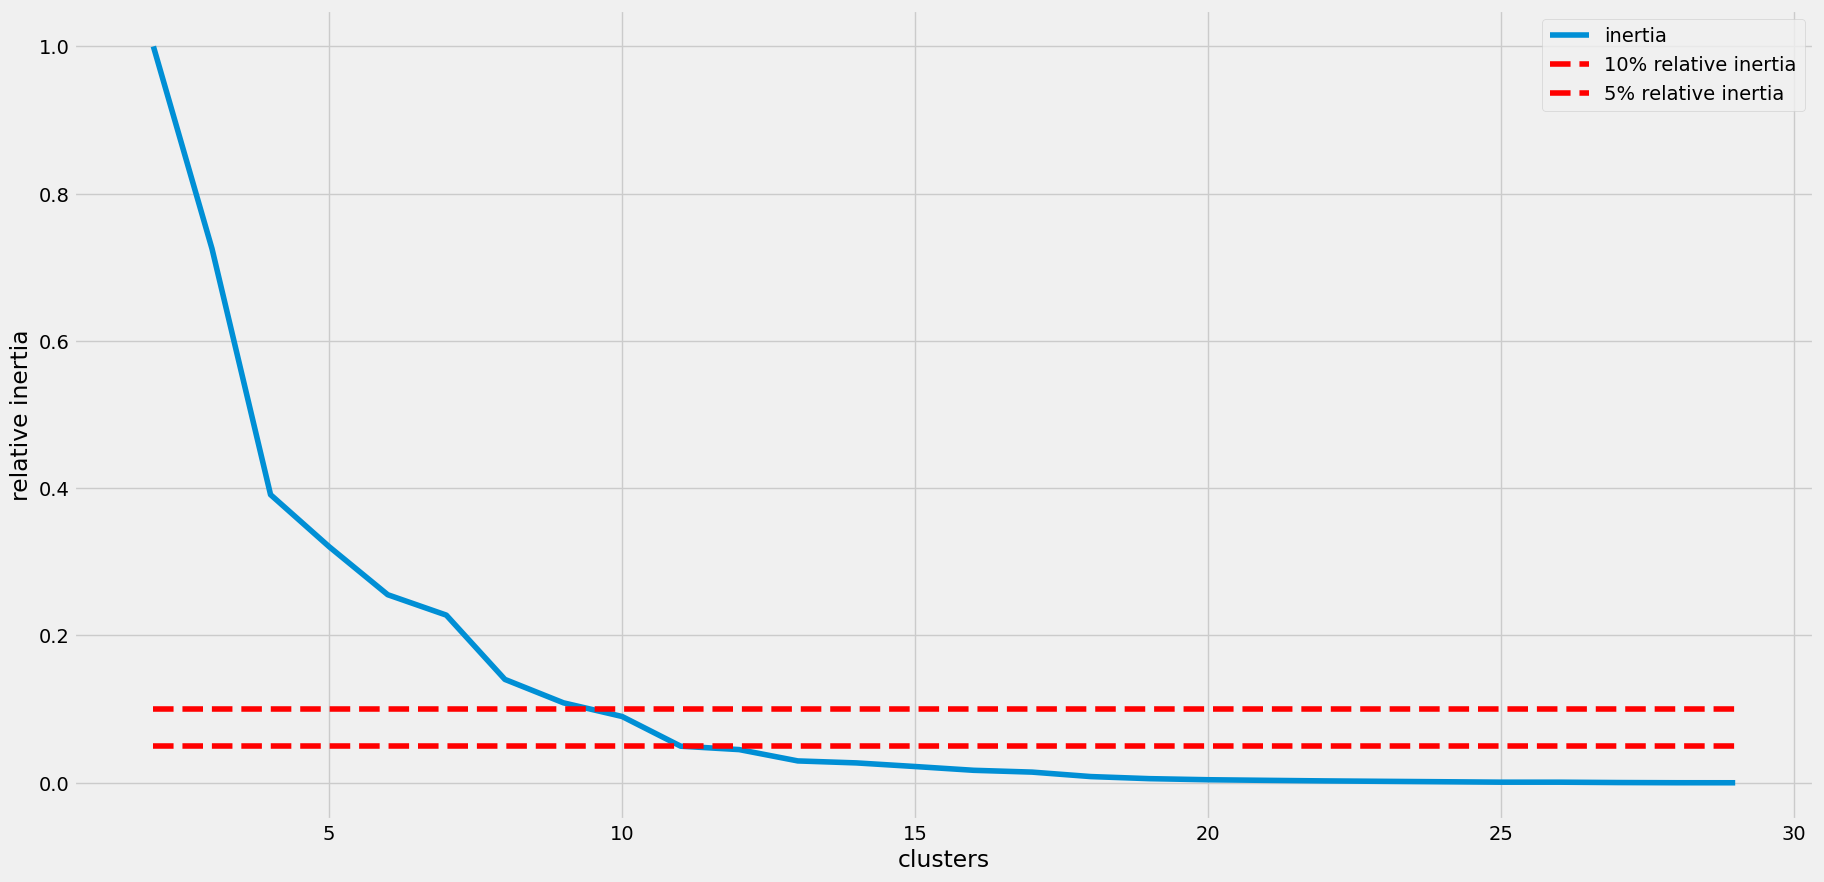

In [14]:
# Elbow Method
n_clusters = range(2, 30)
inertia = []

for n in n_clusters:
    kmeans = KMeans(n_clusters=n)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

plt.plot(n_clusters, np.divide(inertia,inertia[0]))
plt.hlines(0.1, n_clusters[0], n_clusters[-1], 'r', linestyles='dashed')
plt.hlines(0.05, n_clusters[0], n_clusters[-1], 'r', linestyles='dashed')
plt.xlabel('clusters')
plt.ylabel('relative inertia')
plt.legend(['inertia', '10% relative inertia', '5% relative inertia']);

Silhouette Coefficient is another metric measure of how dense and separated are the clusters. Silhouette coefficient values range between -1 and 1. Larger numbers indicate that samples are closer to their clusters than they are to other clusters. Silhouette coefficient implementation is straight forward where the average silhouette coefficient of all the samples is summarized into one score. The `silhouette_score` function needs a minimum of two clusters, or it will raise an exception.

### Build Clusters 
We will now fit the cluster model. Given the timeseries characteristics, the dataset needs to be normalized for the model to work properly. The normalizing can be accomplished by using the `Normalizer` transformer from `Scikit-Learn`

In [15]:
# Normalize and fit the model
model = Pipeline([
    ("normalization", StandardScaler()),
    ("cluster", KMeans(n_clusters=15, n_init=10))
    ])

In [16]:
# Fit Model
model.fit(features) 

# Assign Label
labels = model.predict(features)

# Check lables
labels

array([ 8,  5,  0,  6,  0,  4, 12,  3,  5, 14,  9,  5, 11,  0,  7,  0,  7,
        1, 10, 10, 13,  2,  7, 10,  2,  2,  7,  3,  1], dtype=int32)

In [17]:
# Model parameters
model.get_params()

{'memory': None,
 'steps': [('normalization', StandardScaler()),
  ('cluster', KMeans(n_clusters=15, n_init=10))],
 'transform_input': None,
 'verbose': False,
 'normalization': StandardScaler(),
 'cluster': KMeans(n_clusters=15, n_init=10),
 'normalization__copy': True,
 'normalization__with_mean': True,
 'normalization__with_std': True,
 'cluster__algorithm': 'lloyd',
 'cluster__copy_x': True,
 'cluster__init': 'k-means++',
 'cluster__max_iter': 300,
 'cluster__n_clusters': 15,
 'cluster__n_init': 10,
 'cluster__random_state': None,
 'cluster__tol': 0.0001,
 'cluster__verbose': 0}

In [18]:
# Get the cluster centers
model['cluster'].cluster_centers_

array([[-0.18011295,  0.79228544],
       [-0.19861521, -1.15957035],
       [ 1.35714409,  0.24676602],
       [-1.3953865 ,  0.49702073],
       [ 2.05102261,  2.38323094],
       [ 0.2859916 , -0.11177603],
       [ 0.36991178,  2.10701502],
       [-0.63079503, -1.53393047],
       [ 2.0446058 ,  0.70126725],
       [ 1.37615486, -0.35126231],
       [-0.57593683, -0.66830467],
       [-1.59037573, -0.53406501],
       [-0.76348407,  0.4990253 ],
       [ 1.01466796,  0.12762405],
       [-1.27246443,  0.95878818]])

In [19]:
# Cluster centers dimension
model['cluster'].cluster_centers_.shape

(15, 2)

### Plot Clusters

In [20]:
for i in range(len(features.index)):
    xy = tuple(features.iloc[i, :] + [0, 0.00])
    print(xy)

(0.3066677829367304, 0.2814534522046794)
(0.18897821298580164, 0.24811753030430359)
(0.1370524557100195, 0.2828443307903181)
(0.18829946745209725, 0.3495251060285441)
(0.1606481562644835, 0.2911658656808685)
(0.30712132696781225, 0.3629005311909311)
(0.10819041078136189, 0.2716601275653012)
(0.06817069622200109, 0.26723103442696106)
(0.1687635919537435, 0.24231147213761692)
(0.0722153925873019, 0.29392359488880865)
(0.25942129412814063, 0.23048596766896398)
(0.1893620195297145, 0.23581941051814348)
(0.04974524320164026, 0.22163396552420322)
(0.15607941241341364, 0.2822091470620763)
(0.12123257721522168, 0.16941998151965829)
(0.1439136151514863, 0.2872242519607176)
(0.10368923170501913, 0.1746637141531606)
(0.16555284642170615, 0.19218798492999112)
(0.11167092724782363, 0.2163844697653135)
(0.1313342507552192, 0.20744080465956313)
(0.2338711967829636, 0.25367546676900704)
(0.25248889402474556, 0.2599138974228876)
(0.12199149226559848, 0.17210450938277336)
(0.12133388696783014, 0.2215754

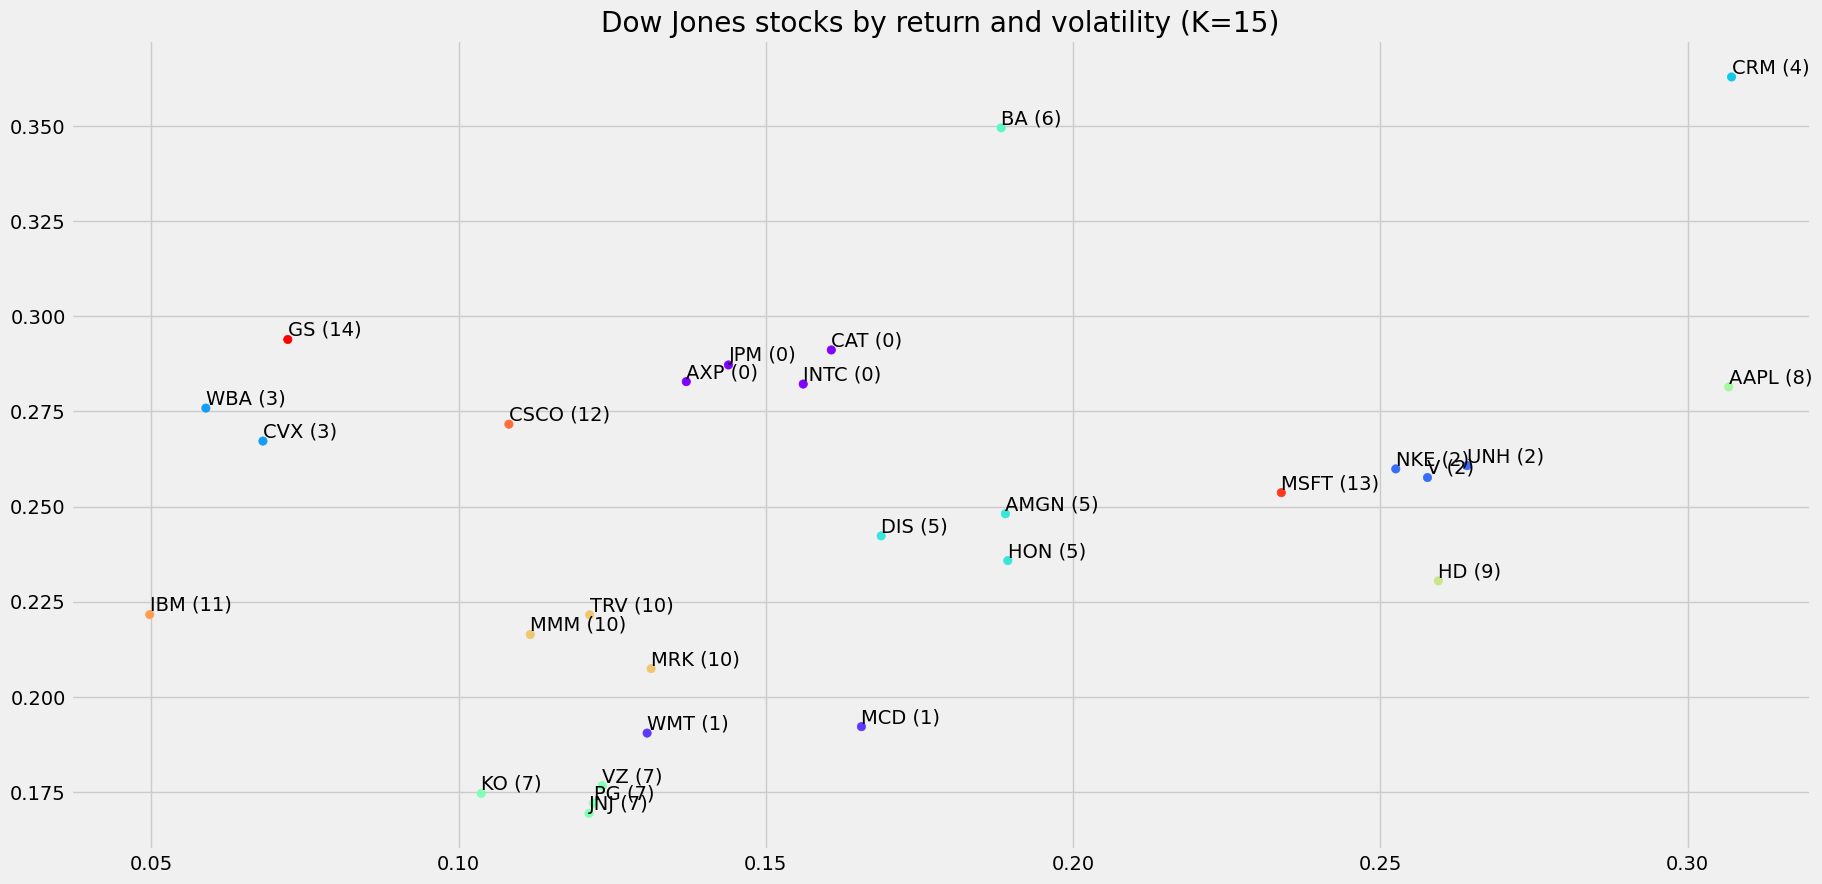

In [21]:
# Plot dow jones stocks clustered by return and volatility
plt.scatter(
    features.returns, 
    features.vol, 
    c=labels, 
    cmap="rainbow",
)

plt.title("Dow Jones stocks by return and volatility (K=15)")
for i in range(len(features.index)):
    txt = f"{features.index[i]} ({labels[i]})"
    xy = tuple(features.iloc[i, :] + [0, 0.001])
    plt.annotate(txt, xy)

In [22]:
# Create dataframe to hold cluster details
cluster_df = pd.DataFrame({'Cluster': labels, 
                    'Companies': dow_stocks,
                    'Returns': features.returns,
                    'Volatility': features.vol,
                    }
                  ).sort_values(by=['Cluster'], axis = 0)

cluster_df = cluster_df.reset_index(drop=True)
cluster_df

,Cluster,Companies,Returns,Volatility
0,0,JPM,0.143914,0.287224
1,0,AXP,0.137052,0.282844
2,0,INTC,0.156079,0.282209
3,0,CAT,0.160648,0.291166
4,1,WMT,0.130678,0.190501
5,1,MCD,0.165553,0.192188
6,2,NKE,0.252489,0.259914
7,2,V,0.257651,0.257647
8,2,UNH,0.264093,0.260774
9,3,CVX,0.068171,0.267231


Thus, using k-means, we have discovered companies that exhibit similar volatility characteristics as measured by the Average True Range (ATR).

In [ ]:
# Save locally to be used in SOM
# cluster_df.to_csv('../data/cluster_df.csv', index=False)

## References 

* [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
* [Silhouette Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)
* [Python Resources](https://github.com/kannansingaravelu/PythonResources)

---
Python Labs by [Kannan Singaravelu](https://www.linkedin.com/in/kannansi)